
# <pre><b>Karri Divya Naidu | U20240091
# <pre><b>Gaganpreet        | U20240198
# <pre><b>THS Eswar Reddy   | U20240027

---


## AI3022 — Search Methods in AI
### Assignment 1, Part 2: Search Algorithm Implementation

**Problem:** *Deterministic Escape from a Dynamically Guarded Mansion*

This notebook implements **Depth First Search (DFS)**, **Breadth First Search (BFS)**, and
**Best First Search**, and runs all three on the same mansion instance used in Part 1.

**Contents**
1. Problem instance ($n=10$ mansion, guards, start, exit)
2. `MoveGen()` and `GoalTest()`
3. Depth First Search
4. Breadth First Search
5. Heuristic function and Best First Search
6. Performance comparison
7. Discussion



## 1. Problem Instance ($n = 10$)



```
      1  2  3  4  5  6  7  8  9 10
row 1  .  .  .  φ  .  .  φ  .  .  .
row 2  .  φ  .  .  .  φ  .  .  .  .
row 3  .  .  #  .  .  φ  .  .  .  .
row 4  .  φ  .  .  .  .  .  .  φ  .
row 5  .  .  .  φ  .  #  .  .  .  .
row 6  .  .  .  .  .  φ  .  .  .  .
row 7  .  .  φ  .  #  .  .  φ  .  .
row 8  .  .  .  #  .  .  φ  .  .  .
row 9  .  φ  .  .  .  #  .  .  .  .
row10  .  .  .  φ  .  .  φ  .  .  E
```

- `φ` = permanently locked room, 16 in total (Constraint 2)
- `#` = guard-free room, 5 in total (Constraint 3)
- `.` = normal traversable room
- `E` = Safe Exit, fixed at $(10,10)$

**Guard patrols.** Two patrol loops confined entirely to traversable, non-locked,
non-guard-free rooms:

- $P_1 = [(1,2),(1,3),(2,3),(2,4),(3,4),(4,4),(4,5),(5,5),(5,3),(5,2),(6,2),(6,3),(6,4),(6,5),(4,5),(3,5),(2,5)]$, $L_1 = 17$.
- $P_2 = [(2,8),(3,8),(4,8),(5,8),(6,8),(6,9),(7,9),(8,9),(8,8),(9,8),(10,8),(10,9),(9,9),(9,10),(8,10),(7,10),(6,10),(5,10),(4,10),(3,10),(2,10),(2,9)]$, $L_2 = 22$.

Both loops are verified in code (the assertions in the next cell) to contain no locked or
guard-free cells.


**Start** is chose by user but **Exit** is fixed. e.g.
- $C_0 = (1,1)$
- $E = (10,10)$.


In [11]:

# n = 10

# locked = {(1,4), (1,7), (2,2), (2,6), (3,6), (4,2), (4,9), (5,4), (6,6), (7,3), (7,8), (8,7), (9,2), (10,4), (10,7)}
# guard_free = {(3,3),(5,6),(7,5),(8,4), (9,6)}

# exit_pos = (10,10)
# start = (1,1)

n = 10

locked = {
    (1,4), (1,7), (2,2), (2,6), (3,6), (4,2), (4,9), (5,4), (6,6), (7,3), (7,8), (8,7), (9,2),
    (10,4), (10,7)
}

guard_free = {
    (3,3),(5,6),(7,5),(8,4), (9,6)
}

exit_pos = (10,10)

start = (1,1)  # can be changed by using get_start_position() function.

patrol1 = [
    (1,2),(1,3),(2,3),(2,4),(3,4),(4,4),(4,5),(5,5),(5,3),(5,2),(6,2),(6,3),(6,4),(6,5),(4,5),(3,5),(2,5)
]   # L1 = 17

patrol2 = [
    (2,8),(3,8),(4,8),(5,8),(6,8),(6,9),(7,9),(8,9),(8,8),(9,8),(10,8),(10,9),(9,9),(9,10),(8,10),(7,10),(6,10),(5,10),(4,10),(3,10),(2,10),(2,9)
]   # L2 = 22

# --- sanity checks some illegal moves ---
assert start not in locked and start != exit_pos, "start must be legal"
for p in patrol1 + patrol2:
    assert p not in locked, f"patrol cell {p} is locked"
    assert p not in guard_free, f"patrol cell {p} is guard-free (Constraint 3 violation)"
    assert p != exit_pos, f"patrol cell {p} coincides with the exit"
assert exit_pos not in locked, "exit must not be locked"

print("Instance OK.")
print("Start C0 =", start, " Exit E =", exit_pos)
print("Guard 1 patrol (L1=%d):" % len(patrol1), patrol1)
print("Guard 2 patrol (L2=%d):" % len(patrol2), patrol2)


Instance OK.
Start C0 = (1, 1)  Exit E = (10, 10)
Guard 1 patrol (L1=17): [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 4), (4, 5), (5, 5), (5, 3), (5, 2), (6, 2), (6, 3), (6, 4), (6, 5), (4, 5), (3, 5), (2, 5)]
Guard 2 patrol (L2=22): [(2, 8), (3, 8), (4, 8), (5, 8), (6, 8), (6, 9), (7, 9), (8, 9), (8, 8), (9, 8), (10, 8), (10, 9), (9, 9), (9, 10), (8, 10), (7, 10), (6, 10), (5, 10), (4, 10), (3, 10), (2, 10), (2, 9)]


In [12]:
def get_start_position():
    """Ask the user for a valid starting position."""

    while True:
        try:
            user_input = input(
                "\nEnter starting position (row column): "
            ).split()

            if len(user_input) != 2:
                print("Please enter exactly two numbers. Example: 1 1")
                continue

            x, y = map(int, user_input)
            start = (x, y)

            # Check boundary
            if not (1 <= x <= n and 1 <= y <= n):
                print(f"Invalid position. Enter a position between 1 and {n}.")
                continue

            # Check locked room
            if start in locked:
                print("Invalid position. This room is permanently locked (φ).")
                continue

            # Check exit
            if start == exit_pos:
                print("Invalid position. The starting position cannot be the exit.")
                continue

            # Check guard position at time 0
            guard1_pos = patrol1[0]
            guard2_pos = patrol2[0]

            if start == guard1_pos or start == guard2_pos:
                print("Invalid position. A guard occupies this room at time 0.")
                continue

            # Valid starting position
            print(f"Starting position selected: {start}")
            return start

        except ValueError:
            print("Invalid input. Please enter two integers. Example: 1 1")

In [13]:

def render_grid():
    '''Prints the mansion layout.'''
    rows = []
    header = "     " + " ".join(f"{c:>2}" for c in range(1, n+1))
    rows.append(header)
    for x in range(1, n+1):
        row_cells = []
        for y in range(1, n+1):
            if (x,y) == exit_pos:
                sym = "E"
            elif (x,y) in locked:
                sym = "\u03c6"
            elif (x,y) in guard_free:
                sym = "#"
            else:
                sym = "."
            row_cells.append(f"{sym:>2}")
        rows.append(f"row{x:>2} " + " ".join(row_cells))
    print("\n".join(rows))




In [14]:
render_grid()

start = get_start_position()

print("\nInitial State:")
print(f"Person: {start}")
print("Time: 0")
print(f"Guard 1: {patrol1[0]}")
print(f"Guard 2: {patrol2[0]}")

      1  2  3  4  5  6  7  8  9 10
row 1  .  .  .  φ  .  .  φ  .  .  .
row 2  .  φ  .  .  .  φ  .  .  .  .
row 3  .  .  #  .  .  φ  .  .  .  .
row 4  .  φ  .  .  .  .  .  .  φ  .
row 5  .  .  .  φ  .  #  .  .  .  .
row 6  .  .  .  .  .  φ  .  .  .  .
row 7  .  .  φ  .  #  .  .  φ  .  .
row 8  .  .  .  #  .  .  φ  .  .  .
row 9  .  φ  .  .  .  #  .  .  .  .
row10  .  .  .  φ  .  .  φ  .  .  E
Starting position selected: (1, 1)

Initial State:
Person: (1, 1)
Time: 0
Guard 1: (1, 2)
Guard 2: (2, 8)



## 2. `MoveGen()` and `GoalTest()`

- **Actions:** $A = \{RIGHT, DOWN, LEFT, UP, WAIT\}$, tried in this fixed order.
- **Constraint 1 (boundary):** $1 \le x \le n,\ 1 \le y \le n$.
- **Constraint 2 (locked room):** $C' \notin \varphi$.
- **Constraint 3 (guard-free rooms):** enforced structurally, by construction of the patrols above.
- **Constraint 4 (guard collision):** $C' \ne G_1(t+1)$ and $C' \ne G_2(t+1)$.
- **Constraint 6 (no person–guard room exchange):** for each guard $G_i$,
  $C' = G_i(t) \wedge G_i(t+1) = C \Rightarrow$ reject.

A state is the triple $S=(x,y,t)$,  $S=(C,t)$ with $C=(x,y)$.


In [15]:

def guard_pos(patrol, t):
    return patrol[t % len(patrol)]

def in_bounds(x, y):
    return 1 <= x <= n and 1 <= y <= n

ACTIONS = {'UP': (-1, 0), 'DOWN': (1, 0), 'LEFT': (0, -1), 'RIGHT': (0, 1), 'WAIT': (0, 0)}
ACTION_ORDER = [ 'RIGHT','DOWN', 'LEFT', 'UP',  'WAIT']

def evaluate_move(state, action):
    '''Applies one action to a state and returns the resulting state, or None if illegal.'''
    x, y, t = state
    dx, dy = ACTIONS[action]
    nx, ny = x + dx, y + dy

    if not in_bounds(nx, ny):                       # Constraint 1
        return None
    if (nx, ny) in locked:                           # Constraint 2
        return None

    t2 = t + 1
    g1_now,  g1_next = guard_pos(patrol1, t), guard_pos(patrol1, t2)
    g2_now,  g2_next = guard_pos(patrol2, t), guard_pos(patrol2, t2)

    if (nx, ny) == g1_next or (nx, ny) == g2_next:    # Constraint 4
        return None
    if (nx, ny) == g1_now and g1_next == (x, y):      # Constraint 6, guard 1
        return None
    if (nx, ny) == g2_now and g2_next == (x, y):      # Constraint 6, guard 2
        return None

    return (nx, ny, t2)

def MoveGen(state):
    '''MoveGen(S) = { S' | S' satisfies all domain constraints }'''
    successors = []
    for a in ACTION_ORDER:
        s2 = evaluate_move(state, a)
        if s2 is not None:
            successors.append(s2)
    return successors

def GoalTest(state):
    '''GoalTest(S): True iff C = E'''
    x, y, t = state
    return (x, y) == exit_pos

# quick demonstration
S0 = (start[0], start[1], 0)
print("S0 =", S0)
print("MoveGen(S0) =", MoveGen(S0))
print("GoalTest(S0) =", GoalTest(S0))


S0 = (1, 1, 0)
MoveGen(S0) = [(1, 2, 1), (2, 1, 1), (1, 1, 1)]
GoalTest(S0) = False


## Functions Definition

In [16]:
def head(lst): return lst[0]
def tail(lst): return lst[1:]
def cons(x, lst): return [x] + lst
def concat(l1, l2): return l1 + l2

# ---- OccursIn(node, nodePairs) ----
def OccursIn(node, nodePairs):
    for pair in nodePairs:
        if pair[0] == node:
            return True
    return False

# ---- RemoveSeen(nodeList, OPEN, CLOSED) ----
def RemoveSeen(nodeList, OPEN, CLOSED):
    if not nodeList:
        return []
    node = head(nodeList)
    if OccursIn(node, OPEN) or OccursIn(node, CLOSED):
        return RemoveSeen(tail(nodeList), OPEN, CLOSED)
    else:
        return cons(node, RemoveSeen(tail(nodeList), OPEN, CLOSED))

# ---- MakePairs(nodeList, parent) ----
def MakePairs(nodeList, parent):
    if not nodeList:
        return []
    return cons((head(nodeList), parent), MakePairs(tail(nodeList), parent))

# ---- MakePairsH(nodeList, parent, h): the (node, parent, h) triple used by Best First Search ----
def MakePairsH(nodeList, parent, h_func):
    if not nodeList:
        return []
    node = head(nodeList)
    return cons((node, parent, h_func(node)), MakePairsH(tail(nodeList), parent, h_func))

# ---- FindLink(node, CLOSED) ----
def FindLink(node, CLOSED):
    for pair in CLOSED:
        if pair[0] == node:
            return pair
    return None

# ---- ReconstructPath(nodePair, CLOSED) ----
def ReconstructPath(nodePair, CLOSED):
    node, parent = nodePair[0], nodePair[1]
    path = cons(node, [])
    while parent is not None:
        path = cons(parent, path)
        link = FindLink(parent, CLOSED)
        parent = link[1] if link is not None else None
    return path




## 4. Depth First Search

`OPEN` is treated as a stack: new
`nodePairs` are placed at the **head** (`newPairs ++ tail(OPEN)`).

**A necessary practical addition — `MAX_DEPTH`.** Because $t$ is part of the state and
increases by exactly 1 on every action (including `WAIT`), the state space here is
formally unbounded: nothing in `MoveGen`/`GoalTest` stops the search from generating states
at arbitrarily large $t$. A literal, unmodified DFS can therefore run forever exploring
ever-larger $t$ along a single branch that never reaches the exit. This is not a flaw in the
algorithm as specified — it is a property of an infinite state space, which can be handled by DBDFS. We reuse that idea here as a thin wrapper: `MoveGen` is treated as returning no
children once $t \ge \texttt{MAX\_DEPTH}$, forcing the search to backtrack instead of
diverging. This changes nothing about *which* states are legal — it only bounds *how far*
any one DFS branch is allowed to run before the algorithm is forced to try another branch.
`MAX_DEPTH = 30` is used below, matching the value used in the code cell that follows.


In [ ]:

MAX_DEPTH = 30

def children_or_cutoff(N):
    if N[2] >= MAX_DEPTH:
        return []
    return MoveGen(N)

def DFS(S):
    OPEN = cons((S, None), [])
    CLOSED = []
    expanded = 0
    max_open = 1
    while OPEN:
        max_open = max(max_open, len(OPEN))
        nodePair = head(OPEN)
        N, _ = nodePair[0], nodePair[1]
        if GoalTest(N):
            return {'path': ReconstructPath(nodePair, CLOSED), 'expanded': expanded,
                    'max_open': max_open, 'closed_size': len(CLOSED)}
        else:
            CLOSED = cons(nodePair, CLOSED)
            expanded += 1
            children = children_or_cutoff(N)
            newNodes = RemoveSeen(children, OPEN, CLOSED)
            newPairs = MakePairs(newNodes, N)
            OPEN = concat(newPairs, tail(OPEN))
    return {'path': None, 'expanded': expanded, 'max_open': max_open, 'closed_size': len(CLOSED)}


In [27]:

import time

t0 = time.perf_counter()
dfs_result = DFS(S0)
dfs_time = time.perf_counter() - t0

print("=== DFS ===")
print("Solution found:", dfs_result['path'] is not None)
print("Path length (states):", len(dfs_result['path']))
print("Nodes expanded:", dfs_result['expanded'])
print("Max OPEN size:", dfs_result['max_open'])
print("Time: %.5f s" % dfs_time)
print()
print("Path:")
print(dfs_result['path'])


=== DFS ===
Solution found: True
Path length (states): 21
Nodes expanded: 20
Max OPEN size: 60
Time: 0.00115 s

Path:
[(1, 1, 0), (1, 2, 1), (1, 3, 2), (2, 3, 3), (2, 4, 4), (2, 5, 5), (3, 5, 6), (4, 5, 7), (4, 6, 8), (4, 7, 9), (4, 8, 10), (5, 8, 11), (5, 9, 12), (5, 10, 13), (6, 10, 14), (6, 9, 15), (7, 9, 16), (7, 10, 17), (8, 10, 18), (9, 10, 19), (10, 10, 20)]



With the given mantion setup and action order `RIGHT, DOWN, LEFT, UP, WAIT` and $C_0=(1,1)$, DFS finds a
clean, direct 21-state path (20 expansions) 





## 5. Breadth First Search

Identical to `DFS` except for a single line: new `nodePairs` are appended at the **rear**
of `OPEN` (`tail(OPEN) ++ newPairs`) instead of the front, exactly as specified.


In [28]:

def BFS(S):
    OPEN = cons((S, None), [])
    CLOSED = []
    expanded = 0
    max_open = 1
    while OPEN:
        max_open = max(max_open, len(OPEN))
        nodePair = head(OPEN)
        N, _ = nodePair[0], nodePair[1]
        if GoalTest(N):
            return {'path': ReconstructPath(nodePair, CLOSED), 'expanded': expanded,
                    'max_open': max_open, 'closed_size': len(CLOSED)}
        else:
            CLOSED = cons(nodePair, CLOSED)
            expanded += 1
            children = children_or_cutoff(N)
            newNodes = RemoveSeen(children, OPEN, CLOSED)
            newPairs = MakePairs(newNodes, N)
            OPEN = concat(tail(OPEN), newPairs)          # <-- the only change from DFS
    return {'path': None, 'expanded': expanded, 'max_open': max_open, 'closed_size': len(CLOSED)}


In [29]:

t0 = time.perf_counter()
bfs_result = BFS(S0)
bfs_time = time.perf_counter() - t0

print("=== BFS ===")
print("Solution found:", bfs_result['path'] is not None)
print("Path length (states):", len(bfs_result['path']))
print("Nodes expanded:", bfs_result['expanded'])
print("Max OPEN size:", bfs_result['max_open'])
print("Time: %.5f s" % bfs_time)
print()
print("Path:")
print(bfs_result['path'])


=== BFS ===
Solution found: True
Path length (states): 19
Nodes expanded: 722
Max OPEN size: 95
Time: 0.06770 s

Path:
[(1, 1, 0), (1, 2, 1), (1, 3, 2), (2, 3, 3), (2, 4, 4), (2, 5, 5), (3, 5, 6), (4, 5, 7), (4, 6, 8), (4, 7, 9), (4, 8, 10), (5, 8, 11), (5, 9, 12), (6, 9, 13), (7, 9, 14), (8, 9, 15), (8, 10, 16), (9, 10, 17), (10, 10, 18)]



Because `OPEN` behaves as a queue, BFS explores states in order of increasing $t$ (depth).
The first goal state it finds is therefore reached in the **fewest possible time steps** —
BFS is guaranteed optimal here.



## 6. Heuristic Function and Best First Search

**Heuristic.** $h(n)$ estimates how "close" a state is to the goal. We use the Manhattan
distance from the person's current room to the Safe Exit, ignoring $t$ (time does not make
one room geometrically closer to another):

$$h\big((x,y,t)\big) = |x - x_E| + |y - y_E|$$

This is a reasonable "goodness" estimate — it decreases as the
person approaches the exit — but it is **not guaranteed optimal or admissible** for this
problem, because it ignores the guards entirely: a state with a small $h$ value may still
require a long detour (or a `WAIT`) to avoid a guard. That trade-off is intentional and
expected for Best First Search

**Algorithm.** Identical structure to `DFS`/`BFS`, except:
- `nodePair` is now a **triple** $(N, parent, h(N))$.
- Line 12 becomes `OPEN ← merge(sortH(newPairs), tail(OPEN))`: the newly generated pairs are
  sorted by $h$ ascending, then merged with the (already $h$-sorted) remainder of `OPEN`, so
  `OPEN` stays sorted by $h$ throughout and the lowest-$h$ node is always at the head.


In [30]:

def h(state):
    x, y, t = state
    return abs(x - exit_pos[0]) + abs(y - exit_pos[1])

def sortH(pairs):
    return sorted(pairs, key=lambda p: p[2])

def merge(l1, l2):
    '''Merges two lists already sorted ascending by h (the 3rd tuple element).'''
    result, i, j = [], 0, 0
    while i < len(l1) and j < len(l2):
        if l1[i][2] <= l2[j][2]:
            result.append(l1[i]); i += 1
        else:
            result.append(l2[j]); j += 1
    result.extend(l1[i:])
    result.extend(l2[j:])
    return result

def BestFirstSearch(S):
    OPEN = cons((S, None, h(S)), [])
    CLOSED = []
    expanded = 0
    max_open = 1
    while OPEN:
        max_open = max(max_open, len(OPEN))
        nodePair = head(OPEN)
        N = nodePair[0]
        if GoalTest(N):
            return {'path': ReconstructPath(nodePair, CLOSED), 'expanded': expanded,
                    'max_open': max_open, 'closed_size': len(CLOSED)}
        else:
            CLOSED = cons(nodePair, CLOSED)
            expanded += 1
            children = children_or_cutoff(N)
            newNodes = RemoveSeen(children, OPEN, CLOSED)
            newPairs = MakePairsH(newNodes, N, h)
            OPEN = merge(sortH(newPairs), tail(OPEN))
    return {'path': None, 'expanded': expanded, 'max_open': max_open, 'closed_size': len(CLOSED)}


In [31]:

t0 = time.perf_counter()
bestfs_result = BestFirstSearch(S0)
bestfs_time = time.perf_counter() - t0

print("=== Best First Search ===")
print("Solution found:", bestfs_result['path'] is not None)
print("Path length (states):", len(bestfs_result['path']))
print("Nodes expanded:", bestfs_result['expanded'])
print("Max OPEN size:", bestfs_result['max_open'])
print("Time: %.5f s" % bestfs_time)
print()
print("Path:")
print(bestfs_result['path'])


=== Best First Search ===
Solution found: True
Path length (states): 21
Nodes expanded: 53
Max OPEN size: 60
Time: 0.00245 s

Path:
[(1, 1, 0), (1, 2, 1), (1, 3, 2), (2, 3, 3), (2, 4, 4), (2, 5, 5), (3, 5, 6), (4, 5, 7), (4, 6, 8), (4, 7, 9), (4, 8, 10), (5, 8, 11), (5, 9, 12), (5, 10, 13), (6, 10, 14), (6, 9, 15), (7, 9, 16), (7, 10, 17), (8, 10, 18), (9, 10, 19), (10, 10, 20)]



## 7. Performance Comparison


In [32]:

results = {
    'DFS':              {'result': dfs_result,     'time': dfs_time},
    'BFS':              {'result': bfs_result,      'time': bfs_time},
    'Best First Search':{'result': bestfs_result,   'time': bestfs_time},
}

print(f"{'Algorithm':<20}{'Path length':<14}{'Nodes expanded':<17}{'Max OPEN':<11}{'Time (s)':<10}")
print("-" * 72)
for name, r in results.items():
    res = r['result']
    plen = len(res['path']) if res['path'] else '-'
    print(f"{name:<20}{plen:<14}{res['expanded']:<17}{res['max_open']:<11}{r['time']:<10.5f}")


Algorithm           Path length   Nodes expanded   Max OPEN   Time (s)  
------------------------------------------------------------------------
DFS                 21            20               60         0.00115   
BFS                 19            722              95         0.06770   
Best First Search   21            53               60         0.00245   


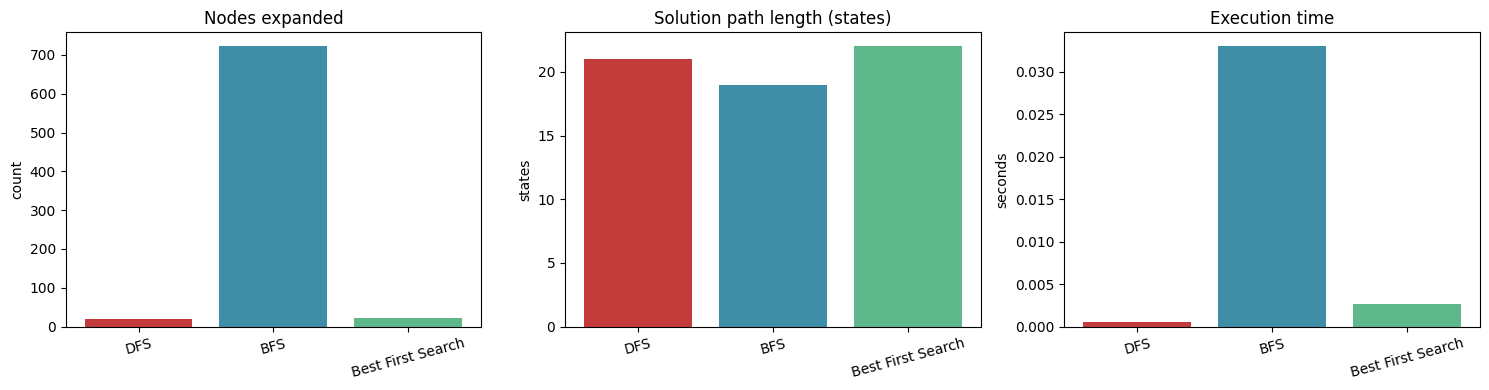

In [34]:

import matplotlib.pyplot as plt

names = list(results.keys())
expanded_vals = [results[n]['result']['expanded'] for n in names]
maxopen_vals  = [results[n]['result']['max_open'] for n in names]
pathlen_vals  = [len(results[n]['result']['path']) for n in names]
time_vals     = [results[n]['time'] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(names, expanded_vals, color=['#C43B3B', '#3F8EA7', '#5FB78C'])
axes[0].set_title('Nodes expanded')
axes[0].set_ylabel('count')

axes[1].bar(names, pathlen_vals, color=['#C43B3B', '#3F8EA7', '#5FB78C'])
axes[1].set_title('Solution path length (states)')
axes[1].set_ylabel('states')

axes[2].bar(names, time_vals, color=['#C43B3B', '#3F8EA7', '#5FB78C'])
axes[2].set_title('Execution time')
axes[2].set_ylabel('seconds')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=130)

plt.show()



## 8. Discussion

**Correctness.** All three algorithms return a sequence of states
$S_0 \to S_1 \to \cdots \to S_k$ with $GoalTest(S_k) = True$ and every transition passing
through the same `MoveGen`, so all three solutions are valid escapes from the
mansion under the same domain constraints (boundary, locked rooms, guard collision, and the
person–guard swap rule).

**DFS.** With the current action order (`RIGHT, DOWN, LEFT, UP, WAIT`) and $C_0=(1,1)$, DFS
finds a 21-state path in only 20 expansions (max $|OPEN|=60$) -- close to BFS's optimal
19-state solution

**BFS.** Explores strictly in order of increasing $t$, so the first goal state it reaches is
automatically reached in the fewest time steps -- 19 states, the shortest possible escape from
$C_0=(1,1)$ in this instance. This optimality is a free side effect of level-order exploration,
even though the problem is explicitly not posed as an optimization problem. BFS pays for this
guarantee with by far the largest number of node expansions of the three (722 in this run),
since it exhaustively explores every state at one depth before moving to the next.

**Best First Search.** Guided by $h(n) = $ Manhattan distance to $E$, it reaches the exit after
21 node expansions and a 22-state path -- 3 states longer than BFS's optimal 19-state path.


**Overall.** For this problem -- a feasibility question over a state space that is technically
unbounded in $t$ -- BFS remains the only one of the three with a built-in optimality guarantee
(fewest time steps), regardless of start position or action order. Best First Search is the
more *consistently* efficient of the remaining two once averaged across different starting
positions, even though this specific run happened to make plain DFS marginally cheaper in
expansions and Best First's path was not the shortest. Plain DFS's practical behaviour is the
least trustworthy of the three: without an externally imposed depth bound, and depending
entirely on the interaction between the fixed action order and where the search happens to
start, it can range from near-optimal (as seen here) to badly degenerate (as seen from other
starting rooms in this same instance).
